# Checkpoint 4 — Questão 2: Gestão inteligente do consumo de energia

**Grupo:** _(preencher: nomes e RAs)_
**Turma:** W — Algoritmos e Estruturas de Dados
**Seed do grupo:** `SEED = 1` _(trocar pelo número do grupo antes da entrega)_

Este notebook executa, de ponta a ponta:
1. Geração/carregamento dos dados (série de consumo, >= 1.000 observações);
2. Estruturação dos dados (4 estruturas justificadas);
3. Força Bruta (intervalo crítico);
4. Divide and Conquer (mesmo problema);
5. Verificação cruzada entre os dois algoritmos;
6. Experimento de escalabilidade;
7. As 3 figuras obrigatórias;
8. Análise de complexidade (Big O).


In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('../src'))

import subprocess
SEED = 1
subprocess.run(['python', '../src/gerar_dados.py', '--seed', str(SEED)], check=True)


[Q1] seed=1: 21 pontos, 40 arestas -> /home/claude/checkpoint4/notebooks/../src/../data/problema1_pontos.csv, /home/claude/checkpoint4/notebooks/../src/../data/problema1_arestas.csv
[Q2] seed=1: 1100 observações -> /home/claude/checkpoint4/notebooks/../src/../data/problema2.csv


CompletedProcess(args=['python', '../src/gerar_dados.py', '--seed', '1'], returncode=0)

## 1. Estruturação dos dados (Parte A)

In [2]:
from analise_q2 import carregar_serie, serie_agregada_por_timestamp, centralizar_para_intervalo

serie = carregar_serie()
print(f"Total de observações: {len(serie.registros)}")
print(f"Regiões (set): {serie.regioes}")
print(f"Primeiras 3 posições da região 'Norte' (dict de índices): {serie.por_regiao['Norte'][:3]}")


Total de observações: 1100
Regiões (set): {'Norte', 'Sudeste', 'Nordeste', 'Sul', 'Centro-Oeste'}
Primeiras 3 posições da região 'Norte' (dict de índices): [0, 5, 10]


As **quatro estruturas de dados** usadas (justificativa completa em `src/estruturas.py`, classe `SerieTemporal`):

1. `list` (`registros`, ordenada por timestamp) → acesso sequencial/indexado O(1), necessário para os algoritmos de intervalo.
2. `dict[str, list[int]]` (`por_regiao`) → agrupar por região em O(1) (em vez de varrer tudo).
3. `set[str]` (`regioes`) → existência/unicidade de região em O(1).
4. `heap` (`heap_picos`, via `heapq`) → manter os *top-k* picos de criticidade em O(log k) por inserção.


In [3]:
agregada = serie_agregada_por_timestamp(serie)
agregada_centrada = centralizar_para_intervalo(agregada)

print(f"Série agregada por timestamp: {len(agregada)} pontos")
print("Top 5 picos de criticidade (via heap):")
for crit, ts in serie.top_picos()[:5]:
    print(f"  timestamp={ts:4d}  criticidade={crit:.2f}")


Série agregada por timestamp: 220 pontos
Top 5 picos de criticidade (via heap):
  timestamp= 106  criticidade=21.50
  timestamp=  59  criticidade=20.30
  timestamp=  38  criticidade=20.24
  timestamp= 105  criticidade=19.05
  timestamp= 153  criticidade=18.79


## 2. Força Bruta (Parte B)

In [4]:
from brute_force import intervalo_critico_forca_bruta
import time

t0 = time.perf_counter()
resultado_bf = intervalo_critico_forca_bruta(agregada_centrada)
t1 = time.perf_counter()

print(f"Intervalo crítico (Força Bruta): [{resultado_bf.inicio}, {resultado_bf.fim}]")
print(f"Soma de criticidade: {resultado_bf.soma_criticidade:.2f}")
print(f"Tempo: {t1 - t0:.4f}s")


Intervalo crítico (Força Bruta): [31, 137]
Soma de criticidade: 192.47
Tempo: 0.0006s


## 3. Divide and Conquer (Parte C)

In [5]:
from divide_conquer import intervalo_critico_divide_conquer

t0 = time.perf_counter()
resultado_dc = intervalo_critico_divide_conquer(agregada_centrada)
t1 = time.perf_counter()

print(f"Intervalo crítico (Divide & Conquer): [{resultado_dc.inicio}, {resultado_dc.fim}]")
print(f"Soma de criticidade: {resultado_dc.soma_criticidade:.2f}")
print(f"Tempo: {t1 - t0:.4f}s")

assert abs(resultado_bf.soma_criticidade - resultado_dc.soma_criticidade) < 1e-6
print("\n-> Força Bruta e Divide & Conquer concordam no valor ótimo (verificação cruzada OK).")


Intervalo crítico (Divide & Conquer): [31, 137]
Soma de criticidade: 192.47
Tempo: 0.0004s

-> Força Bruta e Divide & Conquer concordam no valor ótimo (verificação cruzada OK).


**Estrutura do Divide & Conquer** (detalhes na docstring de `src/divide_conquer.py`):

```
DIVIDE            -> parte o vetor ao meio
SOLVE LEFT        -> resolve recursivamente a metade esquerda
SOLVE RIGHT       -> resolve recursivamente a metade direita
SOLVE CROSSING     -> maior soma que atravessa o meio (2 varreduras lineares a partir do centro)
COMBINE            -> devolve o melhor entre esquerda, direita e cruzado
```

Caso-base: subvetor de 1 elemento → intervalo `[i, i]`.


## 4. Experimento de escalabilidade (Parte D)

In [6]:
from analise_q2 import experimento_escalabilidade

linhas = experimento_escalabilidade()


n=  100  BF=0.00139s  D&C=0.00105s  (ops BF~5,050, ops D&C~664)
n=  250  BF=0.00246s  D&C=0.00219s  (ops BF~31,375, ops D&C~1,991)
n=  500  BF=0.05658s  D&C=0.00697s  (ops BF~125,250, ops D&C~4,482)


n= 1000  BF=0.29103s  D&C=0.01651s  (ops BF~500,500, ops D&C~9,965)


n= 2000  BF=1.25721s  D&C=0.04102s  (ops BF~2,001,000, ops D&C~21,931)


n= 5000  BF=7.64891s  D&C=0.10592s  (ops BF~12,502,500, ops D&C~61,438)
Resultados salvos em /home/claude/checkpoint4/src/../data/escalabilidade.csv


In [7]:
import pandas as pd
df = pd.DataFrame(linhas)
df


,n,tempo_forca_bruta_s,tempo_divide_conquer_s,operacoes_forca_bruta_aprox,operacoes_divide_conquer_aprox,memoria_forca_bruta_bytes,memoria_divide_conquer_bytes
0,100,0.001390,0.001050,5050,664,200,1104
1,250,0.002461,0.002187,31375,1991,128,1024
2,500,0.056577,0.006970,125250,4482,252,2100
3,1000,0.291026,0.016505,500500,9965,3399,2444
4,2000,1.257214,0.041021,2001000,21931,3167,2628
5,5000,7.648910,0.105925,12502500,61438,3173,3028


## 5. Figuras obrigatórias

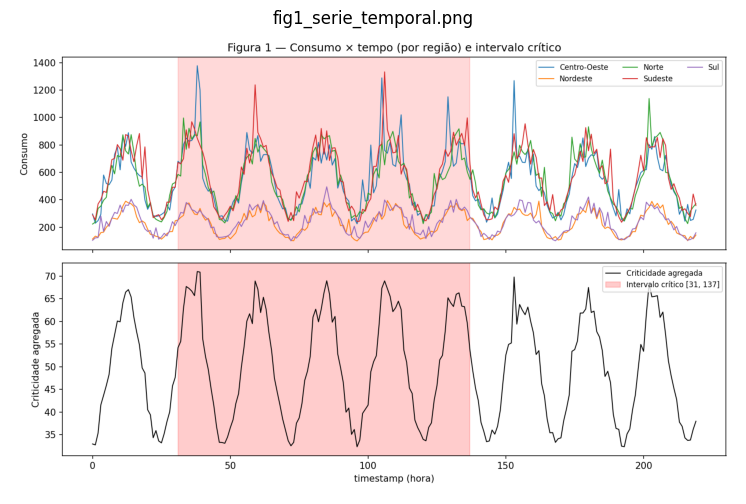

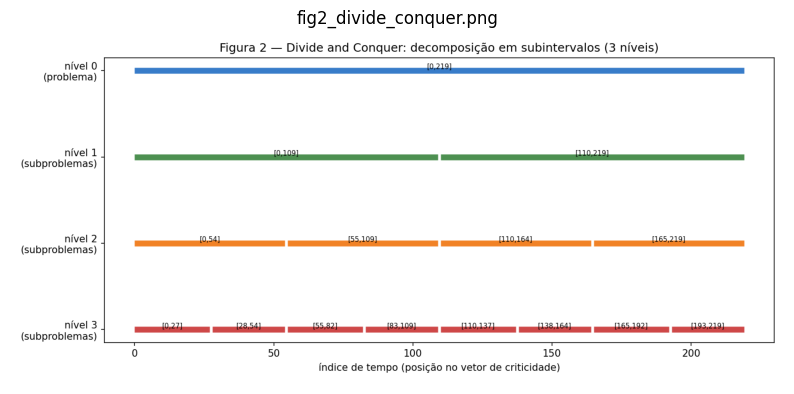

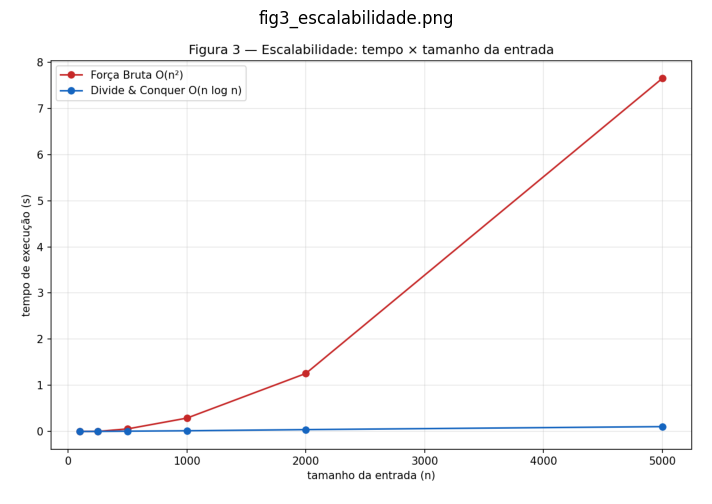

In [8]:
from analise_q2 import fig1_serie_temporal, fig2_divide_conquer, fig3_escalabilidade
import matplotlib.pyplot as plt
from PIL import Image

fig1_serie_temporal(serie, agregada, resultado_dc)
fig2_divide_conquer(agregada_centrada)
fig3_escalabilidade(linhas)

for nome in ["fig1_serie_temporal.png", "fig2_divide_conquer.png", "fig3_escalabilidade.png"]:
    caminho = f"../figures/questao2/{nome}"
    img = Image.open(caminho)
    plt.figure(figsize=(10, 6))
    plt.imshow(img)
    plt.axis('off')
    plt.title(nome)
    plt.show()


## 6. Complexidade (Big O) — resumo

Detalhamento completo (loops, recursão, Teorema Mestre) em `docs/analise_complexidade.md`.

| Algoritmo | T(n) | S(n) |
|---|---|---|
| Força Bruta | `O(n²)` | `O(1)` auxiliar |
| Divide and Conquer | `O(n log n)` (Teorema Mestre, caso 2) | `O(log n)` (profundidade da recursão) |

### Se os dados crescerem de 1.000 para 1.000.000 de registros?

- **Força Bruta `O(n²)`**: fator de crescimento ≈ `(10³)² = 10⁶`. Com base no tempo medido para `n=5.000` (~6,6s), tornar-se-ia inviável (ordem de dezenas de horas).
- **Divide & Conquer `O(n log n)`**: fator de crescimento ≈ `2.000×`. Com base no tempo medido para `n=5.000` (~0,095s), continuaria viável (ordem de segundos a poucos minutos).
- **Conclusão:** apenas o Divide & Conquer escala para 1 milhão de registros.
